### Data Import

import data from https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

In [165]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# fetch dataset 
chronic_kidney_disease = fetch_ucirepo(id=336) 
  
# data (as pandas dataframes) 
x = chronic_kidney_disease.data.features 
y = chronic_kidney_disease.data.targets 

In [166]:
x.describe(include='all')

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
count,391.000000,388.000000,353.000000,354.000000,351.000000,248,335,396,396,356.000000,...,348.000000,329.000000,294.000000,269.000000,398,398,398,399,399,399
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,NaN,...,NaN,NaN,NaN,NaN,2,3,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,normal,normal,notpresent,notpresent,NaN,...,NaN,NaN,NaN,NaN,no,no,no,good,no,no
freq,NaN,NaN,NaN,NaN,NaN,201,259,354,374,NaN,...,NaN,NaN,NaN,NaN,251,260,364,317,323,339
mean,51.483376,76.469072,1.017408,1.016949,0.450142,NaN,NaN,NaN,NaN,148.036517,...,12.526437,38.884498,8406.122449,4.707435,NaN,NaN,NaN,NaN,NaN,NaN
std,17.169714,13.683637,0.005717,1.352679,1.099191,NaN,NaN,NaN,NaN,79.281714,...,2.912587,8.990105,2944.474190,1.025323,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000,50.000000,1.005000,0.000000,0.000000,NaN,NaN,NaN,NaN,22.000000,...,3.100000,9.000000,2200.000000,2.100000,NaN,NaN,NaN,NaN,NaN,NaN
25%,42.000000,70.000000,1.010000,0.000000,0.000000,NaN,NaN,NaN,NaN,99.000000,...,10.300000,32.000000,6500.000000,3.900000,NaN,NaN,NaN,NaN,NaN,NaN
50%,55.000000,80.000000,1.020000,0.000000,0.000000,NaN,NaN,NaN,NaN,121.000000,...,12.650000,40.000000,8000.000000,4.800000,NaN,NaN,NaN,NaN,NaN,NaN
75%,64.500000,80.000000,1.020000,2.000000,0.000000,NaN,NaN,NaN,NaN,163.000000,...,15.000000,45.000000,9800.000000,5.400000,NaN,NaN,NaN,NaN,NaN,NaN


lets check dtypes to see what kind of data we're working with and to get a clear list of existing colunmns


In [167]:
x.dtypes

age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc          str
pc           str
pcc          str
ba           str
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn          str
dm           str
cad          str
appet        str
pe           str
ane          str
dtype: object

### Renaming and dropping columns
Next lets rename columns to the expected names and drop unused ones, on the rename function usused was
renamed to same name to keep track of which need to be dropped

In [168]:
x = x.rename(columns={
    'bp': 'blood pressure',
    'sg': 'specific gravity',
    'al': 'albumin',
    'su': 'sugar',
    'rbc': 'rbc',
    'pc': 'pc',
    'pcc': 'pcc',
    'ba': 'ba',
    'bgr': 'blood glucose random',
    'bu': 'blood urea',
    'sc': 'sc',
    'sod': 'sodium',
    'pot': 'potassium',
    'hemo': 'hemoglobin',
    'pcv': 'packed cell volume',
    'wbcc': 'white blood cell count',
    'rbcc': 'red blood cell count',
    'htn': 'htn',
    'dm': 'dm',
    'cad': 'cad',
    'appet': 'appet',
    'pe': 'pe',
    'ane': 'ane'
})
x = x.drop(columns=['rbc', 'pc', 'pcc', 'ba', 'sc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'])
x.head()

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,15.4,44.0,7800.0,5.2
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,11.3,38.0,6000.0,NaN
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,9.6,31.0,7500.0,NaN
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,11.2,32.0,6700.0,3.9
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,11.6,35.0,7300.0,4.6


### Class data renaming
from dtypes we can see that only 1 column which contains class data, from checking unique we can see theres ckd\t which needs to be cleaned up

In [169]:
y.dtypes
y['class'].unique()

<StringArray>
['ckd', 'ckd\t', 'notckd']
Length: 3, dtype: str

In [170]:
y['class'] = y['class'].replace({'ckd\t':'a', 'ckd': 'a', 'notckd':'c'})
y.head()

,class
0,a
1,a
2,a
3,a
4,a


### Merging class data from second frame
since we have no ids we can just create a new column on x and assign it to y.class

In [171]:
x['class'] = y['class']

### Converting hemo from g/dl to g/l
google tells us the conversion rate is 1:10, so lets just apply a lambda for that

In [172]:
x['hemoglobin'] = x['hemoglobin'].apply(lambda x: x * 10)
x

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,113.0,38.0,6000.0,NaN,a
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,96.0,31.0,7500.0,NaN,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


### Dropping fields with 3 or more NA values
for this we can just use .dropna with thresh parameter, we have 14 columns so atleast 12 needs to have data for it to be kept, thus we assign thresh=12

In [173]:
x = x.dropna(thresh=12)
x

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,142.0,3.2,122.0,39.0,7800.0,4.4,a
6,68.0,70.0,1.010,0.0,0.0,100.0,54.0,104.0,4.0,124.0,36.0,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


### Splitting dataset to affected and control
creating 2 new dataframes from x filtered by class

In [174]:
affected = x[x['class']=='a']
control = x[x['class']=='c']

In [175]:
affected

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,142.0,3.2,122.0,39.0,7800.0,4.4,a
6,68.0,70.0,1.010,0.0,0.0,100.0,54.0,104.0,4.0,124.0,36.0,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,62.0,90.0,1.020,2.0,1.0,169.0,48.0,138.0,2.9,134.0,47.0,11000.0,6.1,a
244,64.0,90.0,1.015,3.0,2.0,463.0,64.0,135.0,4.1,122.0,40.0,9800.0,4.6,a
246,48.0,110.0,1.015,3.0,0.0,106.0,215.0,120.0,5.7,86.0,26.0,5000.0,2.5,a
248,59.0,70.0,1.010,1.0,3.0,424.0,55.0,138.0,4.5,126.0,37.0,10200.0,4.1,a


In [176]:
control

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
250,40.0,80.0,1.025,0.0,0.0,140.0,10.0,135.0,5.0,150.0,48.0,10400.0,4.5,c
251,23.0,80.0,1.025,0.0,0.0,70.0,36.0,150.0,4.6,170.0,52.0,9800.0,5.0,c
252,45.0,80.0,1.025,0.0,0.0,82.0,49.0,147.0,4.4,159.0,46.0,9100.0,4.7,c
253,57.0,80.0,1.025,0.0,0.0,119.0,17.0,135.0,4.7,154.0,42.0,6200.0,6.2,c
254,51.0,60.0,1.025,0.0,0.0,99.0,38.0,135.0,3.7,130.0,49.0,8300.0,5.2,c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


In [177]:
affected.describe()

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
count,123.000000,125.000000,125.000000,126.000000,126.000000,120.000000,125.000000,108.000000,108.000000,125.000000,125.000000,113.000000,108.000000
mean,57.081301,80.720000,1.013560,1.849206,0.809524,181.200000,80.420000,133.731481,4.751852,106.432000,32.440000,9450.442478,3.976852
std,14.465104,15.769305,0.004527,1.437038,1.366539,93.549394,60.501346,7.666661,4.203592,21.896507,7.150908,3720.458015,0.844510
min,6.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,104.000000,2.500000,31.000000,9.000000,2600.000000,2.100000
25%,49.500000,70.000000,1.010000,0.250000,0.000000,107.000000,37.000000,131.750000,3.800000,95.000000,29.000000,7100.000000,3.400000
50%,60.000000,80.000000,1.015000,2.000000,0.000000,158.000000,60.000000,136.000000,4.200000,108.000000,33.000000,9200.000000,3.900000
75%,65.000000,90.000000,1.015000,3.000000,1.000000,241.250000,107.000000,139.000000,4.900000,120.000000,37.000000,11000.000000,4.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,322.000000,145.000000,47.000000,161.000000,52.000000,26400.000000,8.000000


In [178]:
control.describe()

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
count,139.000000,137.000000,139.000000,139.0,139.0,135.000000,135.000000,136.000000,136.000000,137.000000,138.000000,136.000000,136.000000
mean,46.568345,71.313869,1.022482,0.0,0.0,107.385185,32.874074,141.735294,4.335294,151.883212,46.246377,7708.088235,5.380882
std,15.903719,8.559267,0.002509,0.0,0.0,18.747730,11.482257,4.792332,0.596351,12.845270,4.107695,1815.164727,0.592986
min,12.000000,60.000000,1.020000,0.0,0.0,70.000000,10.000000,135.000000,3.300000,130.000000,40.000000,4300.000000,4.500000
25%,34.000000,60.000000,1.020000,0.0,0.0,93.000000,23.500000,138.000000,3.700000,141.000000,43.000000,6300.000000,4.900000
50%,46.000000,70.000000,1.020000,0.0,0.0,107.000000,33.000000,141.000000,4.500000,150.000000,46.000000,7450.000000,5.300000
75%,58.000000,80.000000,1.025000,0.0,0.0,123.500000,44.000000,146.000000,4.900000,162.000000,50.000000,9225.000000,5.900000
max,80.000000,80.000000,1.025000,0.0,0.0,140.000000,50.000000,150.000000,5.000000,178.000000,54.000000,11000.000000,6.500000


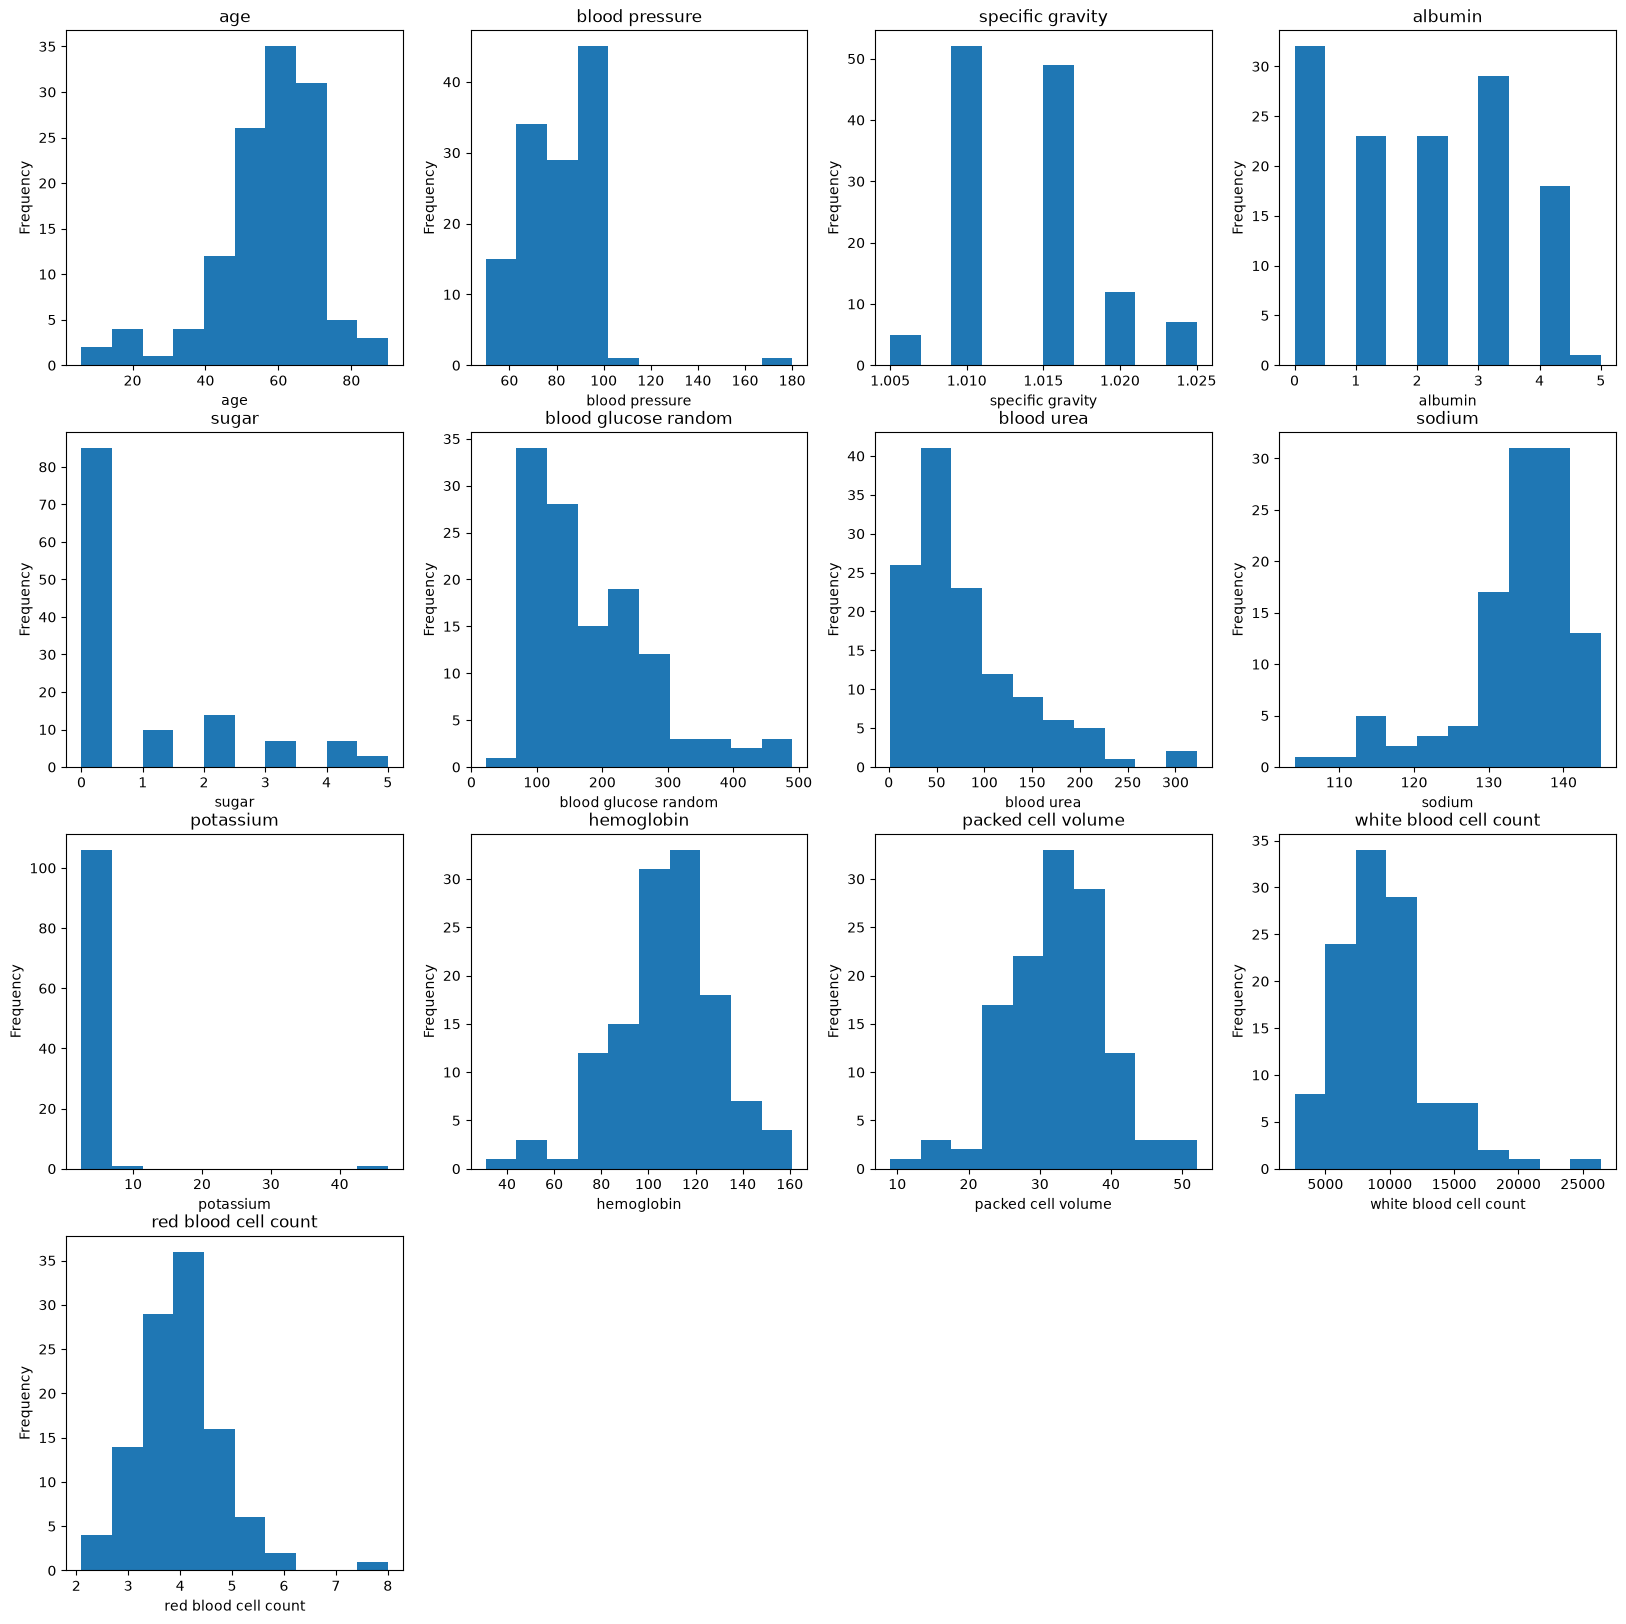

In [179]:
def plot_data(df):
    plt.figure(figsize=(20,20))
    for i, col in enumerate(df.select_dtypes(include=['float64'])):
        plt.subplot(4,4,i+1)
        df[col].plot(kind='hist', title=col)
        plt.xlabel(col)
plot_data(affected)      

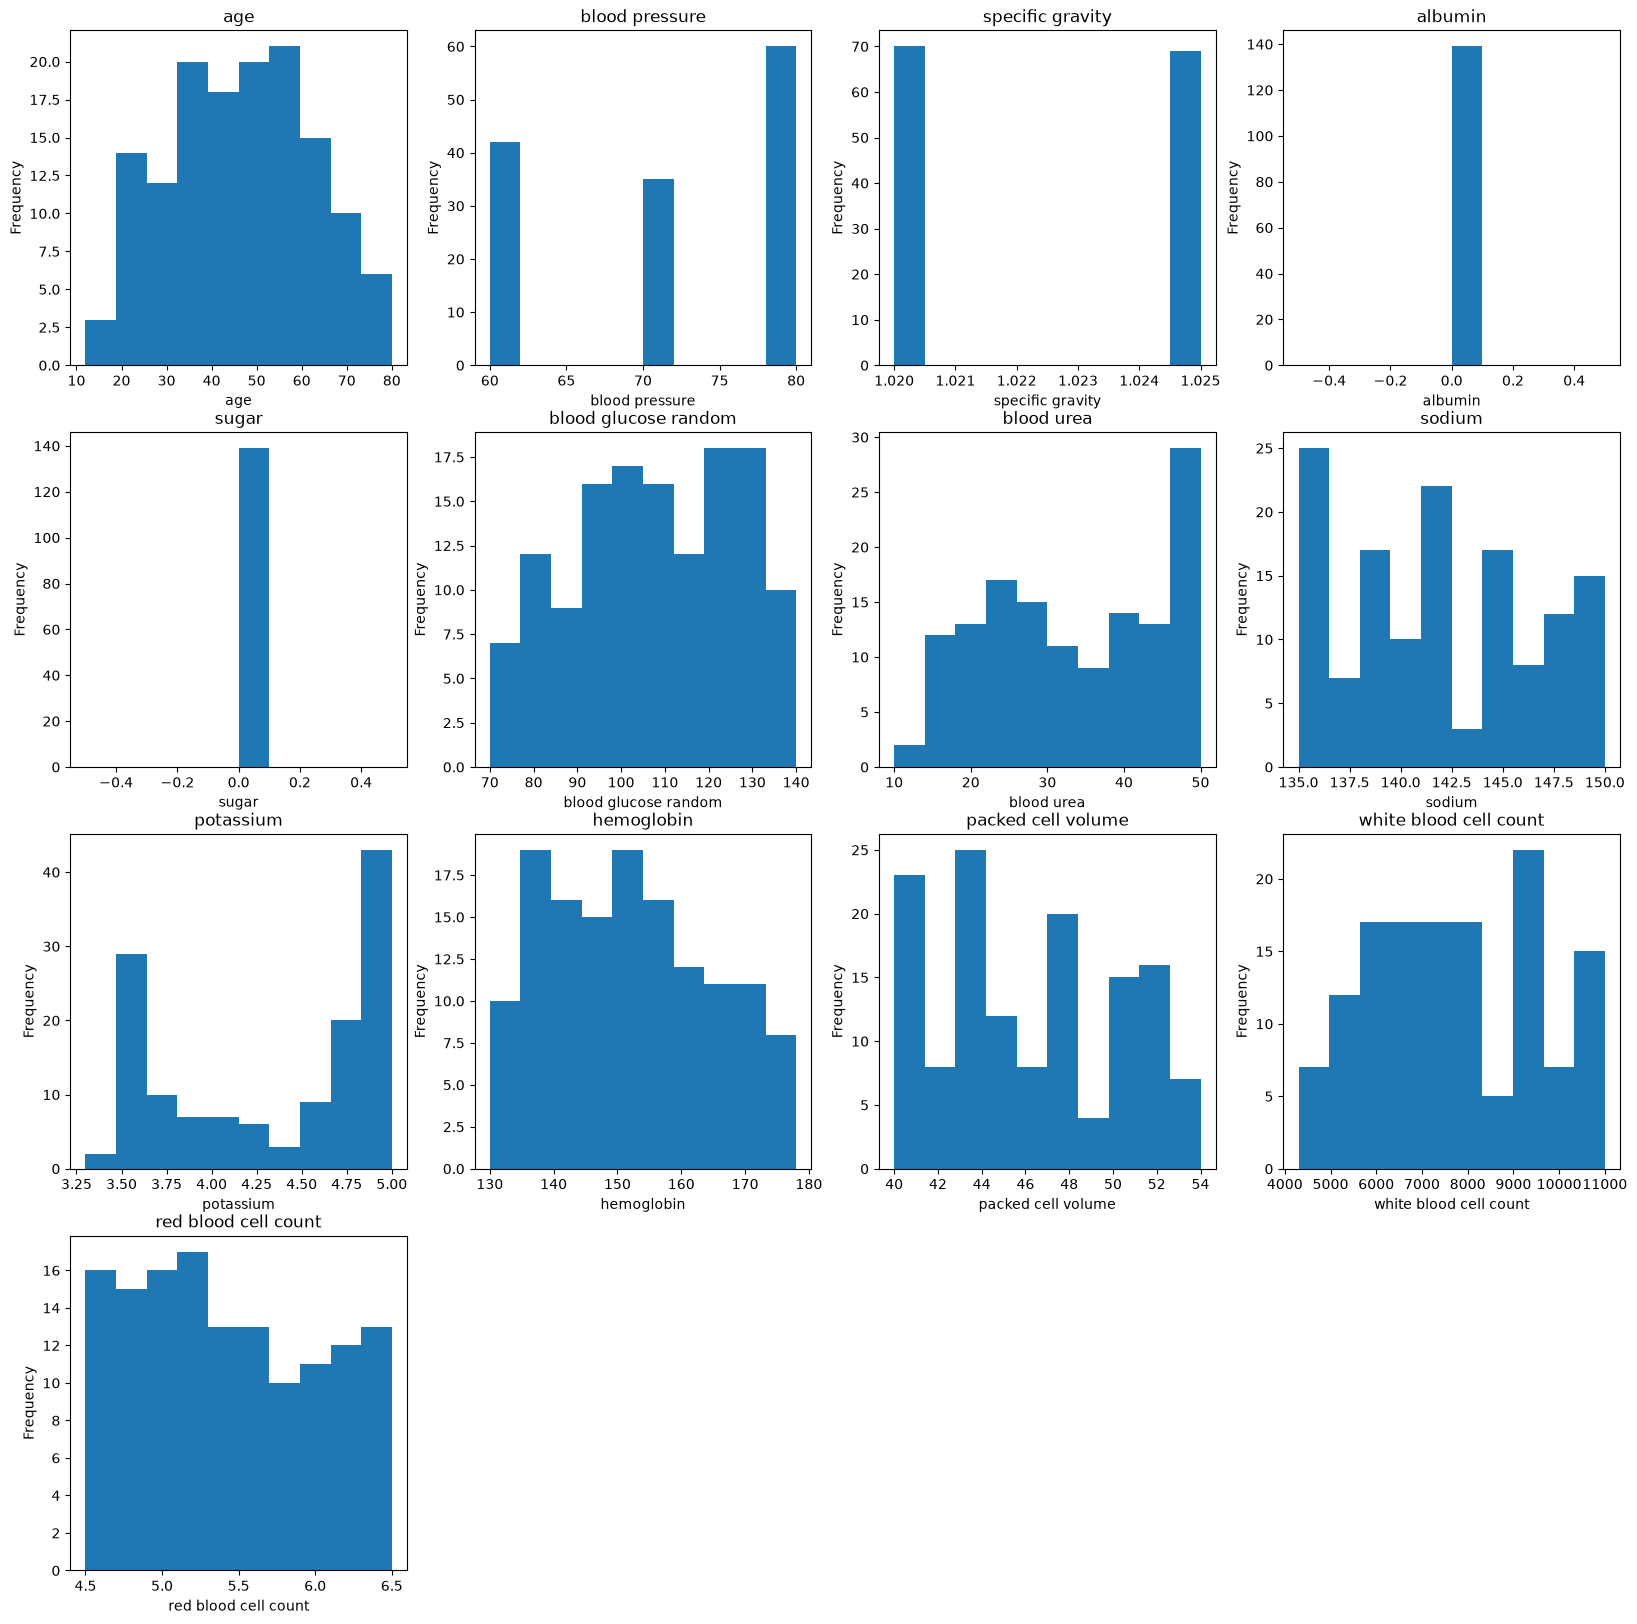

In [180]:
plot_data(control)

### Abnormal values
control group looks good and doesnt have any abnormalities, affected group has dangerously high bp (180), potassium 40 (which is not possible value), those are easy to filter out 

In [181]:
affected['blood pressure'] = affected['blood pressure'].apply(lambda x: affected['blood pressure'].mean() if x >= 120 else x)
affected['potassium'] = affected['potassium'].apply(lambda x: affected['potassium'].mean() if x >= 20 else x)

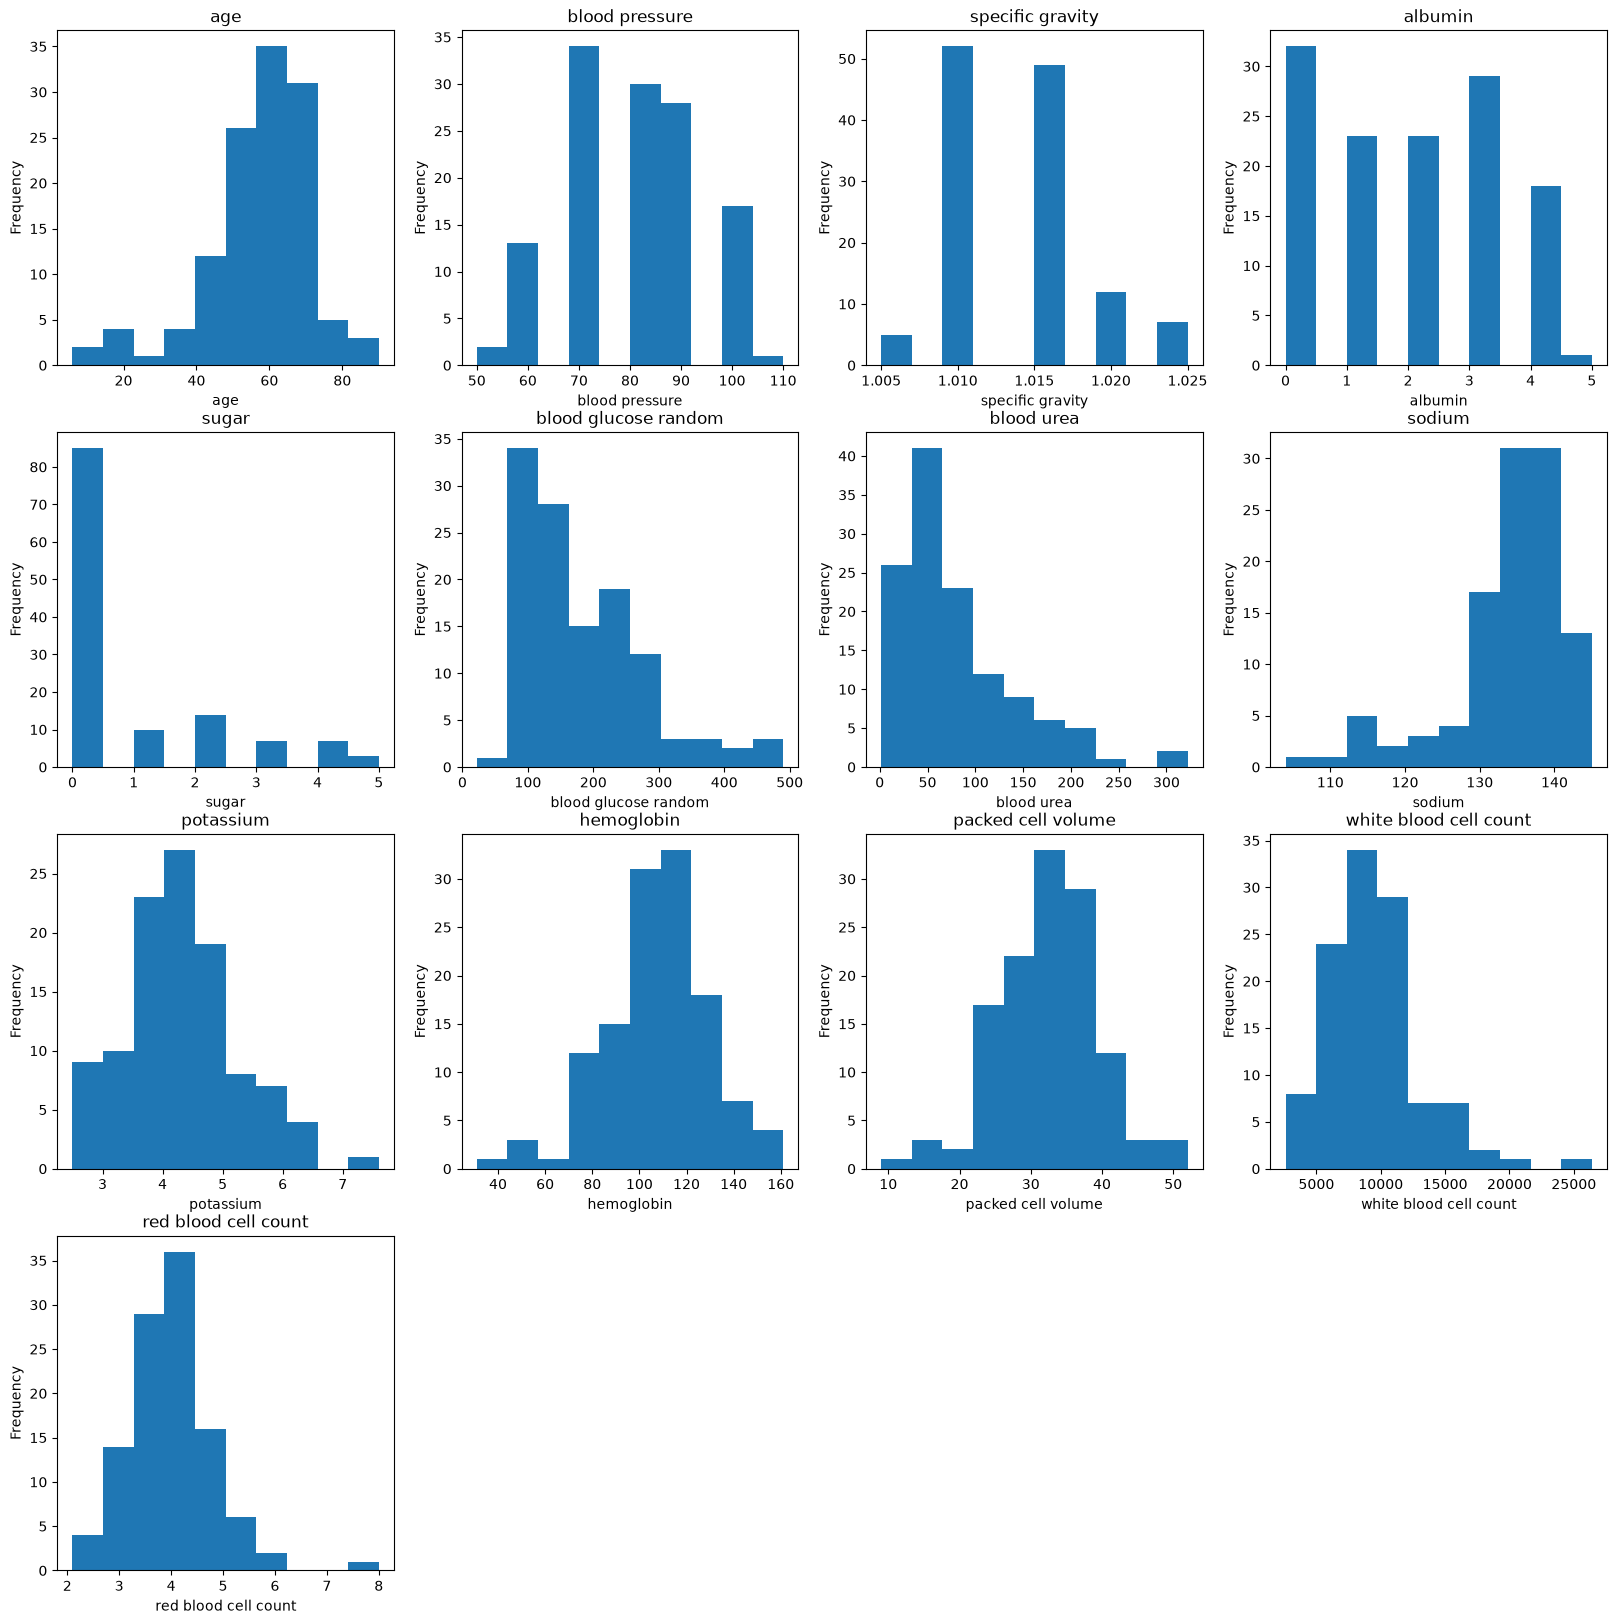

In [182]:
plot_data(affected)

now its looking better, rbcc and wbcc and blood urea still have an outlier value but as far as i know those are still realistic so those are left in

In [183]:
aff_corr = affected.drop(columns=['class']).corr()
con_corr = control.drop(columns=['class']).corr()

In [184]:
aff_corr

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
age,1.000000,0.081835,-0.004869,-0.016726,0.138945,0.205133,0.022593,-0.033951,0.111232,-0.006174,-0.044467,0.015848,-0.016616
blood pressure,0.081835,1.000000,0.066651,0.107188,0.077281,-0.029883,0.136728,0.135018,0.120690,-0.135786,-0.123814,-0.066513,0.098064
specific gravity,-0.004869,0.066651,1.000000,-0.061509,-0.044993,-0.083967,-0.037977,0.143235,0.082478,0.114042,0.106808,-0.026688,0.120779
albumin,-0.016726,0.107188,-0.061509,1.000000,0.115618,0.099096,0.426974,-0.179331,0.217515,-0.371257,-0.329337,0.067898,-0.231920
sugar,0.138945,0.077281,-0.044993,0.115618,1.000000,0.692159,-0.053597,0.052022,0.013426,0.184927,0.120275,0.103631,0.091519
blood glucose random,0.205133,-0.029883,-0.083967,0.099096,0.692159,1.000000,-0.029130,-0.053968,-0.096963,0.144666,0.097501,0.049505,0.140348
blood urea,0.022593,0.136728,-0.037977,0.426974,-0.053597,-0.029130,1.000000,-0.320019,0.339326,-0.608652,-0.568745,-0.135999,-0.487755
sodium,-0.033951,0.135018,0.143235,-0.179331,0.052022,-0.053968,-0.320019,1.000000,0.054192,0.295139,0.317933,0.019716,0.266934
potassium,0.111232,0.120690,0.082478,0.217515,0.013426,-0.096963,0.339326,0.054192,1.000000,-0.369684,-0.377807,-0.209017,-0.310905
hemoglobin,-0.006174,-0.135786,0.114042,-0.371257,0.184927,0.144666,-0.608652,0.295139,-0.369684,1.000000,0.951500,0.071613,0.779202


In [185]:
con_corr

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
age,1.000000,-0.071093,-0.092814,NaN,NaN,0.101408,0.078620,0.110581,-0.094361,0.056334,-0.009969,0.128762,-0.045118
blood pressure,-0.071093,1.000000,0.084470,NaN,NaN,0.004094,-0.084057,-0.107489,-0.064606,0.157748,-0.007854,-0.098981,-0.030603
specific gravity,-0.092814,0.084470,1.000000,NaN,NaN,-0.038416,-0.050116,-0.033880,0.074253,0.026303,-0.007082,-0.028054,0.067207
albumin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sugar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blood glucose random,0.101408,0.004094,-0.038416,NaN,NaN,1.000000,-0.067850,-0.007900,0.146784,-0.147729,-0.257604,-0.069143,-0.196675
blood urea,0.078620,-0.084057,-0.050116,NaN,NaN,-0.067850,1.000000,0.005475,0.047313,0.085647,0.116931,0.041256,-0.010890
sodium,0.110581,-0.107489,-0.033880,NaN,NaN,-0.007900,0.005475,1.000000,0.065758,-0.011060,-0.001524,0.338373,-0.092615
potassium,-0.094361,-0.064606,0.074253,NaN,NaN,0.146784,0.047313,0.065758,1.000000,0.099223,-0.168690,0.041307,-0.052842
hemoglobin,0.056334,0.157748,0.026303,NaN,NaN,-0.147729,0.085647,-0.011060,0.099223,1.000000,0.057235,-0.191126,0.075912


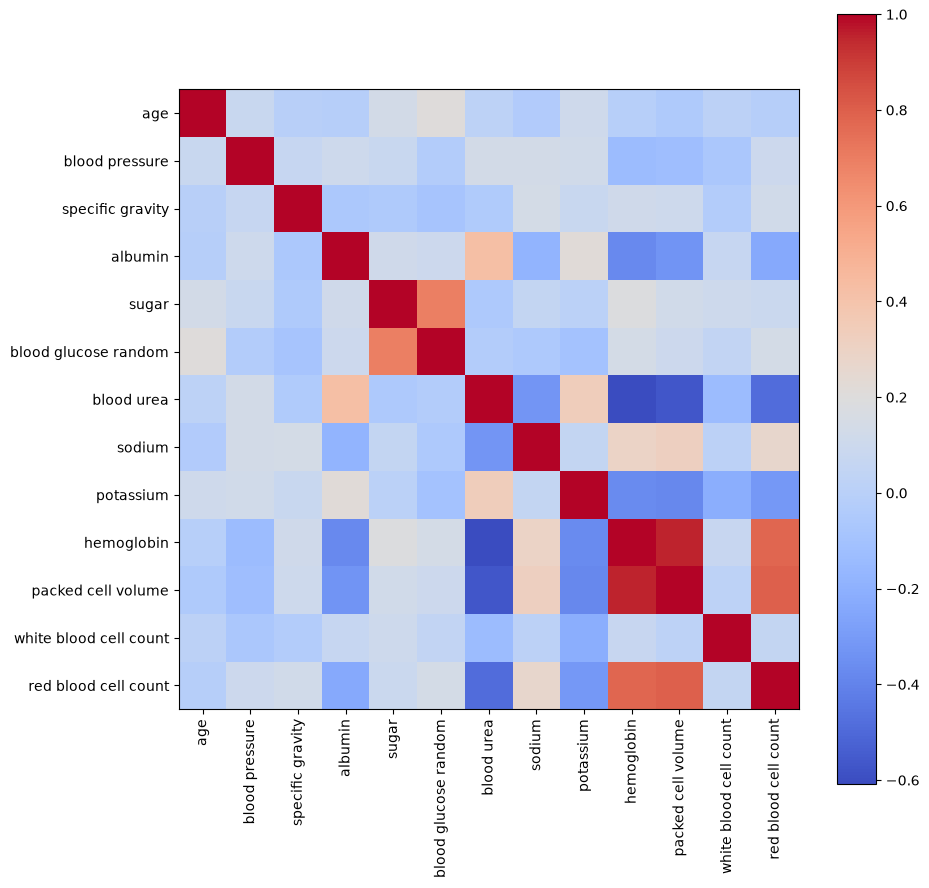

In [186]:
plt.figure(figsize=(10, 10))
plt.imshow(aff_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(aff_corr)), aff_corr.columns, rotation=90)
plt.yticks(range(len(aff_corr)), aff_corr.columns)
plt.show()

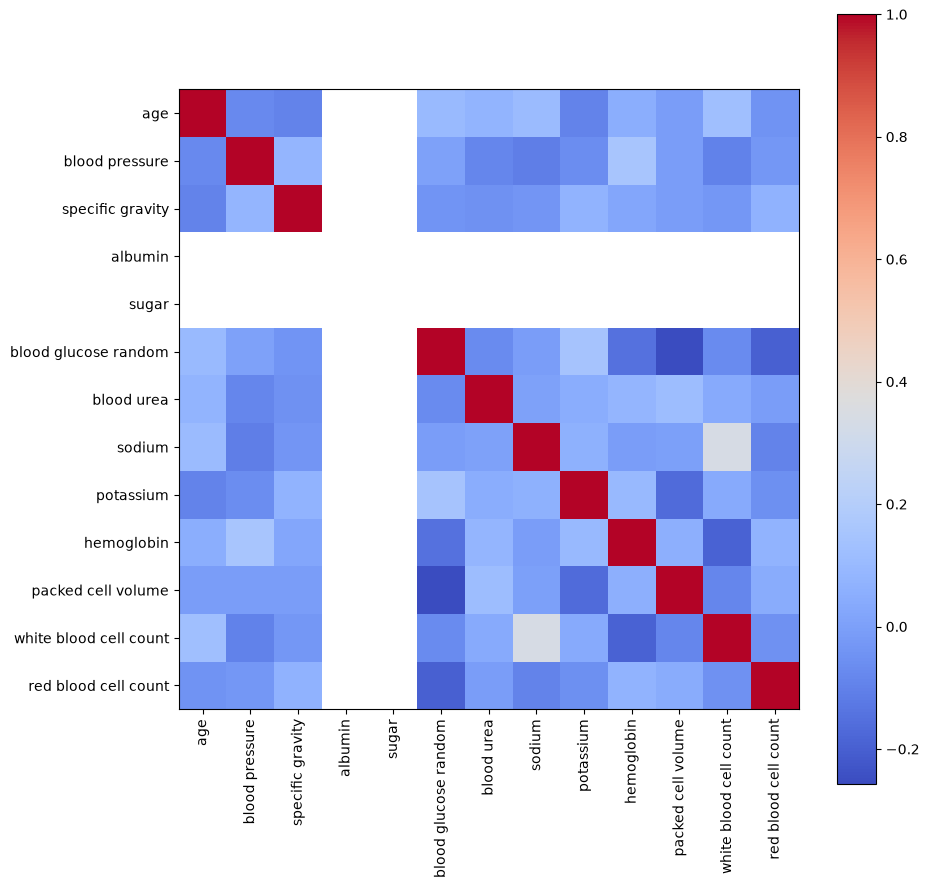

In [187]:
plt.figure(figsize=(10, 10))
plt.imshow(con_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(con_corr)), con_corr.columns, rotation=90)
plt.yticks(range(len(con_corr)), con_corr.columns)
plt.show()

Hemoglobin and packed cell value have very high correlation for affected group but relatively small for control.

In affected group also hemoglobin and red blood cell count has high correlation. 

Blood urea has strong negative correlation for packed cell volume and red blood cell count.

For control group albumin and sugar was 0 so no variance there which is also noteworthy.